In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("loss_by_turn_progress.csv")
df

,model,turn_progress_bin,brier_mean,brier_std,log_loss_mean,log_loss_std,n_samples
0,grouped_mlp,0.0-0.1,0.108519,0.002077,0.371208,0.007629,162603
1,grouped_mlp,0.1-0.2,0.102704,0.003959,0.347655,0.015455,160749
2,grouped_mlp,0.2-0.3,0.099899,0.003766,0.334291,0.014185,161407
3,grouped_mlp,0.3-0.4,0.095450,0.003861,0.316522,0.012719,160642
4,grouped_mlp,0.4-0.5,0.087874,0.006198,0.290092,0.018169,159542
5,grouped_mlp,0.5-0.6,0.083185,0.008623,0.272828,0.021962,159110
6,grouped_mlp,0.6-0.7,0.078896,0.007991,0.257383,0.020928,154567
7,grouped_mlp,0.7-0.8,0.071094,0.007816,0.227467,0.024413,149289
8,grouped_mlp,0.8-0.9,0.059815,0.006405,0.191993,0.019588,144273
9,grouped_mlp,0.9-1.0,0.048388,0.006144,0.157537,0.015815,134884


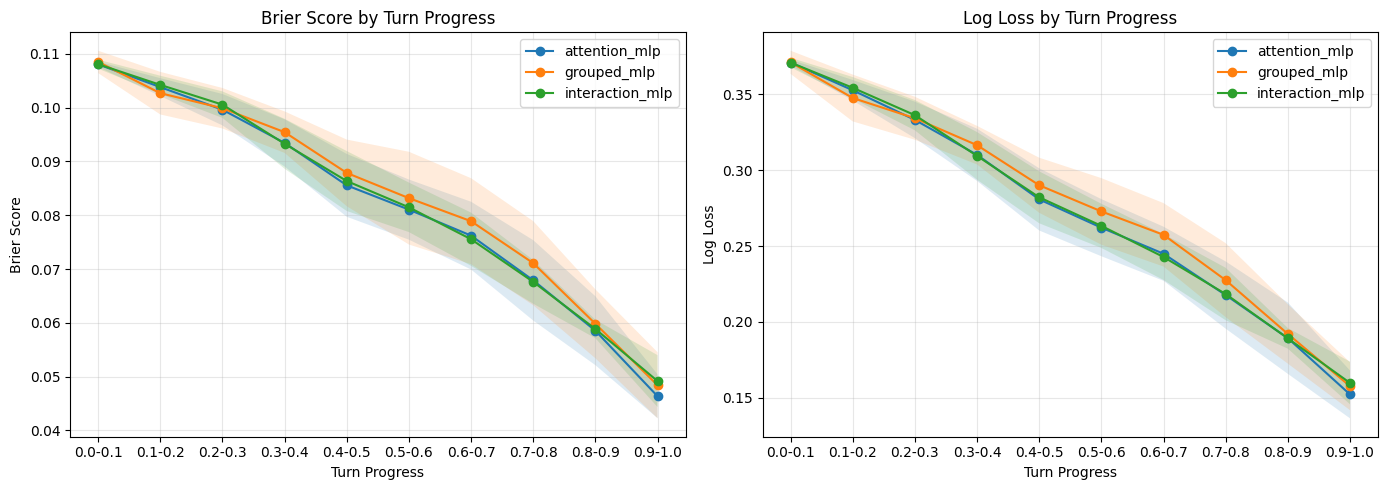

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model, grp in df.groupby("model"):
    axes[0].plot(grp["turn_progress_bin"], grp["brier_mean"], marker="o", label=model)
    axes[0].fill_between(
        grp["turn_progress_bin"],
        grp["brier_mean"] - grp["brier_std"],
        grp["brier_mean"] + grp["brier_std"],
        alpha=0.15,
    )

axes[0].set_xlabel("Turn Progress")
axes[0].set_ylabel("Brier Score")
axes[0].set_title("Brier Score by Turn Progress")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for model, grp in df.groupby("model"):
    axes[1].plot(grp["turn_progress_bin"], grp["log_loss_mean"], marker="o", label=model)
    axes[1].fill_between(
        grp["turn_progress_bin"],
        grp["log_loss_mean"] - grp["log_loss_std"],
        grp["log_loss_mean"] + grp["log_loss_std"],
        alpha=0.15,
    )

axes[1].set_xlabel("Turn Progress")
axes[1].set_ylabel("Log Loss")
axes[1].set_title("Log Loss by Turn Progress")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()